## Imports

In [1]:
import sys

sys.path.append("../")

import json

import numpy as np
import pandas as pd

from docplex.mp.model import Model
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister
from qiskit.primitives import BackendEstimatorV2, StatevectorEstimator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_addon_opt_mapper.converters import OptimizationProblemToQubo
from qiskit_addon_opt_mapper.translators import from_docplex_mp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService
from tqdm import tqdm

from dicke_state_ansatz import DickeStateAnsatz
from utils import plot_hamiltonian_expval_heatmap, plot_hamiltonian_expval_surface

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open(file="../../secrets/credentials.json", mode="rt") as f:
    credentials = json.load(f)

In [3]:
service = QiskitRuntimeService(**credentials)

qiskit_runtime_service._discover_account:WARNING:2026-05-06 19:39:39,840: Loading account with the given token. A saved account will not be used.


In [4]:
statevec_estimator = StatevectorEstimator()
noiseless_sim = AerSimulator(method="statevector", device="CPU")
pm = generate_preset_pass_manager(backend=noiseless_sim, optimization_level=0)

In [5]:
assets_data = pd.read_csv(filepath_or_buffer="../datasets/sp500_assets_close_price.csv", index_col=0)

# Pure state

In [5]:
np.random.seed(seed=42)
tickers = np.random.choice(assets_data.columns, size=3, replace=False)

In [6]:
assets_close_price = assets_data[tickers]

In [7]:
assets_pct_change = assets_close_price.pct_change().dropna()

In [8]:
covariance_annualized = assets_pct_change.cov()*np.sqrt(252)
returns_annualized = assets_pct_change.mean()*252

In [9]:
q = 0.5
b = 1
return_risk_free = 0.0375
weights_array = np.array([1/b for _ in range(assets_close_price.columns.shape[0])])

In [10]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@(x*weights_array))+return_risk_free)
model.add_constraint(x.sum() == b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);
dvar bool x(2);

minimize
 - 0.073237 x(0) + 0.006494 x(1) - 0.050421 x(2) [ 0.005641 x(0)^2
 - 0.000466 x(0)*x(1) + 0.000173 x(0)*x(2) + 0.001649 x(1)^2
 + 0.000596 x(1)*x(2) + 0.001870 x(2)^2 ] + 0.037500;
 
subject to {
 x(0) + x(1) + x(2) == 1;

}
None


In [11]:
result = model.solve()

In [12]:
result.objective_value

-0.030096636453820262

In [13]:
result_array = np.array([result.get_value(f"x({i})") for i in range(assets_close_price.columns.shape[0])])

In [14]:
result_array

array([1., 0., 0.])

In [15]:
quad_model = from_docplex_mp(model=model)
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
ising, offset = qubo.to_ising()

In [16]:
qc = DickeStateAnsatz().generate_quantum_circuit(n=len(tickers), k=b, measurement=False)

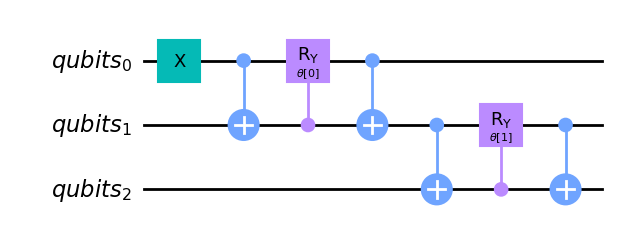

In [17]:
qc.draw(output="mpl", style="clifford")

In [ ]:
theta0 = np.linspace(0, 2*np.pi, 101)
theta1 = np.linspace(0, 2*np.pi, 101)
pubs = [
    (qc, ising, (angle0, angle1))
    for angle0 in theta0 for angle1 in theta1
]

## StatevectorEstimator

In [20]:
estimator_job = statevec_estimator.run(pubs=pubs)
estimator_result = estimator_job.result()

In [21]:
expvals = np.array([estimator_result[i].data.evs + offset for i in range(len(pubs))])
expvals = expvals.reshape((101, 101))

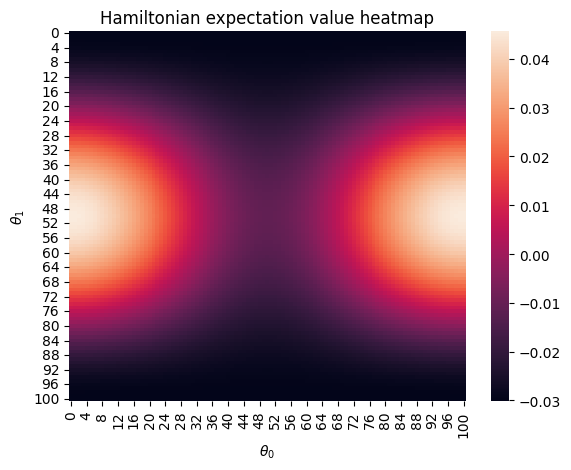

In [22]:
plot_hamiltonian_expval_heatmap(data=expvals)

In [23]:
plot_hamiltonian_expval_surface(x=theta0, y=theta1, z=expvals)

## BackendEstimatorV2 - Noiseless simulator

In [26]:
expvals_dict = {}

for n_shots in tqdm([64, 128, 256, 512, 1024, 2048, 4096]):

    noiseless_estimator = BackendEstimatorV2(backend=noiseless_sim, options=dict(default_precision=1/np.sqrt(n_shots)))
    estimator_job = noiseless_estimator.run(pubs=pubs)
    estimator_result = estimator_job.result()
    expvals = np.array([estimator_result[i].data.evs + offset for i in range(len(pubs))])
    expvals = expvals.reshape((101, 101))
    expvals_dict[n_shots] = expvals

100%|██████████| 7/7 [00:52<00:00,  7.54s/it]


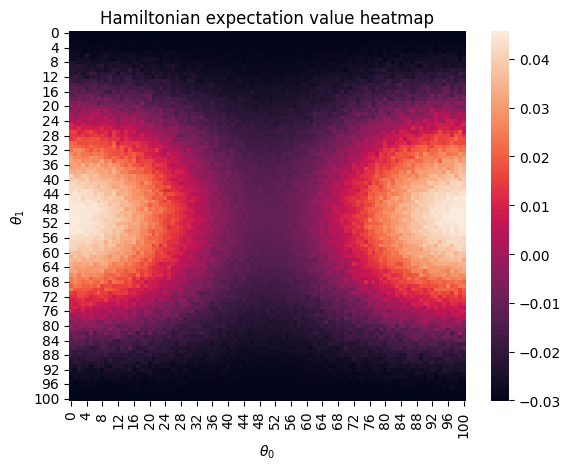

In [27]:
plot_hamiltonian_expval_heatmap(data=expvals_dict[256])

In [28]:
plot_hamiltonian_expval_surface(x=theta0, y=theta1, z=expvals_dict[256])

## BackendEstimatorV2 - Noisy simulator 

In [29]:
backend = service.backend(name="ibm_kingston")
noise_model = NoiseModel.from_backend(backend=backend)
noisy_sim = AerSimulator(method="statevector", device="CPU", noise_model=noise_model)
noisy_estimator = BackendEstimatorV2(backend=noisy_sim, options=dict(default_precision=1/np.sqrt(4096)))

In [31]:
estimator_job = noisy_estimator.run(pubs=pubs)
estimator_result = estimator_job.result()

In [32]:
expvals = np.array([estimator_result[i].data.evs + offset for i in range(len(pubs))])
expvals = expvals.reshape((101, 101))

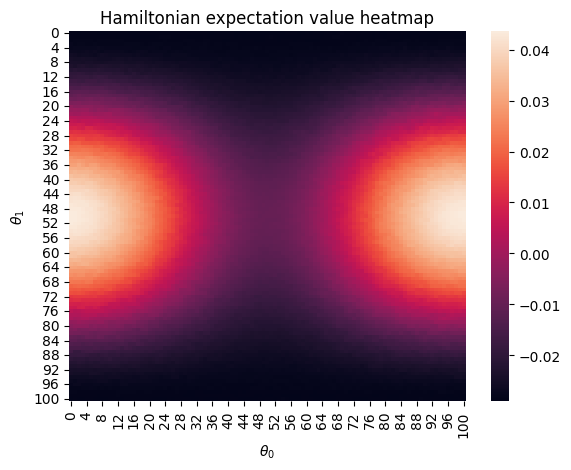

In [33]:
plot_hamiltonian_expval_heatmap(data=expvals)

In [34]:
plot_hamiltonian_expval_surface(x=theta0, y=theta1, z=expvals)

# Mixture

In [6]:
np.random.seed(seed=42)
tickers = np.random.choice(assets_data.columns, size=2, replace=False)

In [7]:
assets_close_price = assets_data[tickers]

In [8]:
assets_pct_change = assets_close_price.pct_change().dropna()

In [9]:
covariance_annualized = assets_pct_change.cov()*np.sqrt(252)
returns_annualized = assets_pct_change.mean()*252

In [10]:
q = 0.5
b = 2
return_risk_free = 0.0375
weights_array = np.ones(shape=(b,))

In [11]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@(x*weights_array))+return_risk_free)
model.add_constraint(x.sum() <= b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);

minimize
 - 0.073237 x(0) + 0.006494 x(1) [ 0.005641 x(0)^2 - 0.000466 x(0)*x(1)
 + 0.001649 x(1)^2 ] + 0.037500;
 
subject to {
 x(0) + x(1) <= 2;

}
None


In [12]:
result = model.solve()

In [13]:
result.objective_value

-0.030096636453820262

In [14]:
result_array = np.array([result.get_value(f"x({i})") for i in range(assets_close_price.columns.shape[0])])

In [15]:
result_array

array([1., 0.])

In [16]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@(x*weights_array))+return_risk_free)

In [17]:
quad_model = from_docplex_mp(model=model)
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
ising, offset = qubo.to_ising()

In [18]:
identity = SparsePauliOp(data="I", coeffs=[1])
ising_expanded = ising.tensor(other=identity)

In [19]:
n = ising.num_qubits
qubits = QuantumRegister(size=3, name="q")
gamma = Parameter(name=r"$\gamma$")


qc = QuantumCircuit(qubits)
qc.ry(theta=gamma, qubit=qubits[0])

params_names = {1: "alpha", 2: "beta"}

for k in range(1,3):
    dicke = DickeStateAnsatz().generate_quantum_circuit(n=n, k=k, measurement=False, param_name=params_names[k])
    if k == 1:
        qc.x(qubit=qubits[0])
    dicke_gate = dicke.to_gate(label=rf"$\vert D^{n}_{k} \rangle$").control(1)
    qc.append(dicke_gate, qargs=range(qubits.size))
    if k == 1:
        qc.x(qubit=qubits[0])

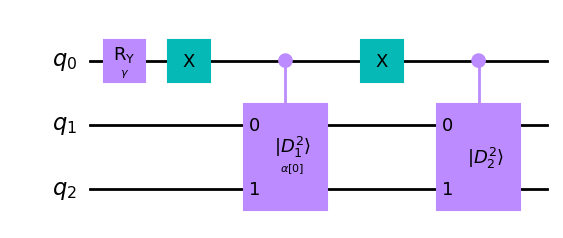

In [20]:
qc.draw(output="mpl", style="clifford")

In [21]:
qc = pm.run(circuits=qc)

In [22]:
gamma = np.linspace(0, 2*np.pi, 101)
alpha = np.linspace(0, 2*np.pi, 101)
pubs = [
    (qc, ising_expanded, (angle0, angle1))
    for angle0 in gamma for angle1 in alpha
]

## StatevectorEstimator

In [34]:
estimator_job = statevec_estimator.run(pubs=pubs)
estimator_result = estimator_job.result()

In [35]:
expvals = np.array([estimator_result[i].data.evs + offset for i in range(len(pubs))])
expvals = expvals.reshape((101, 101))

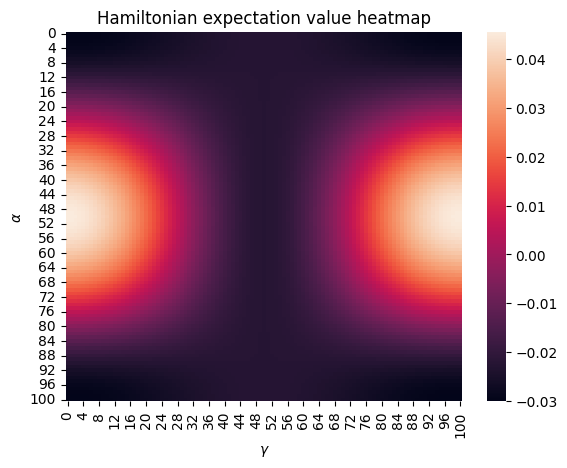

In [36]:
plot_hamiltonian_expval_heatmap(data=expvals, xlabel=r"$\gamma$", ylabel=r"$\alpha$")

In [37]:
plot_hamiltonian_expval_surface(x=gamma, y=alpha, z=expvals, xlabel="gamma", ylabel="alpha")

## BackendEstimatorV2 - Noiseless simulator

In [27]:
expvals_dict = {}

for n_shots in tqdm([64, 128, 256, 512, 1024, 2048, 4096]):

    noiseless_estimator = BackendEstimatorV2(backend=noiseless_sim, options=dict(default_precision=1/np.sqrt(n_shots)))
    estimator_job = noiseless_estimator.run(pubs=pubs)
    estimator_result = estimator_job.result()
    expvals = np.array([estimator_result[i].data.evs + offset for i in range(len(pubs))])
    expvals = expvals.reshape((101, 101))
    expvals_dict[n_shots] = expvals

100%|██████████| 7/7 [01:07<00:00,  9.67s/it]


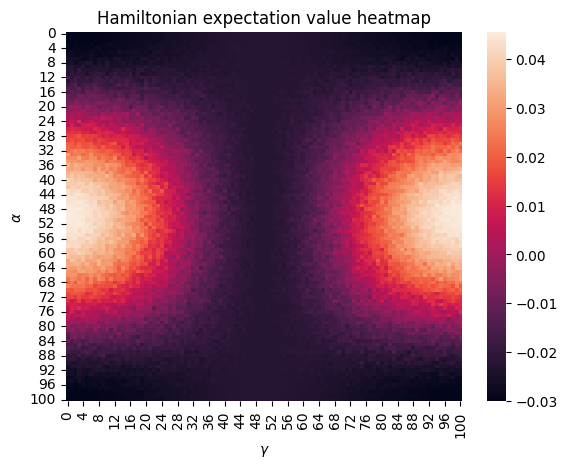

In [31]:
plot_hamiltonian_expval_heatmap(data=expvals_dict[256], xlabel=r"$\gamma$", ylabel=r"$\alpha$")

In [33]:
plot_hamiltonian_expval_surface(x=gamma, y=alpha, z=expvals_dict[256], xlabel="gamma", ylabel="alpha")

## BackendEstimatorV2 - Noisy simulator

In [38]:
backend = service.backend(name="ibm_kingston")
noise_model = NoiseModel.from_backend(backend=backend)
noisy_sim = AerSimulator(method="statevector", device="CPU", noise_model=noise_model)
noisy_estimator = BackendEstimatorV2(backend=noisy_sim, options=dict(default_precision=1/np.sqrt(4096)))

In [39]:
estimator_job = noisy_estimator.run(pubs=pubs)
estimator_result = estimator_job.result()

In [40]:
expvals = np.array([estimator_result[i].data.evs + offset for i in range(len(pubs))])
expvals = expvals.reshape((101, 101))

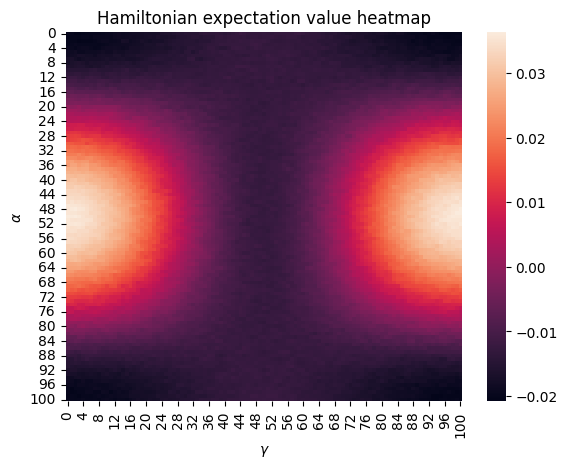

In [41]:
plot_hamiltonian_expval_heatmap(data=expvals, xlabel=r"$\gamma$", ylabel=r"$\alpha$")

In [42]:
plot_hamiltonian_expval_surface(x=gamma, y=alpha, z=expvals, xlabel="gamma", ylabel="alpha")